In [1]:
# Bibliotecas
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
# Exibe uma janela para a seleção de um arquivo
from google.colab import files
arquivo = files.upload()
img_name = next(iter(arquivo))
print(img_name)

Saving L-RES.png to L-RES.png
L-RES.png


**Leitura da imagem e Extração de dados**

In [105]:

imagem = cv2.imread(img_name)
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
print("Dimensões da imagem: ", imagem.shape)

Dimensões da imagem:  (40, 40, 3)


**Translação**

Text(0.5, 1.0, 'Imagem Transladada')

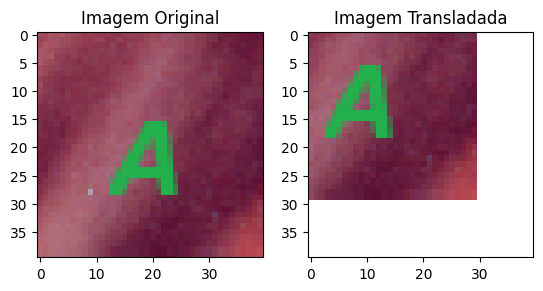

In [106]:
matriz = np.zeros_like(imagem)

for i in range(imagem.shape[0]):
  for j in range(imagem.shape[1]):

    if i+10 < imagem.shape[0] and j+10 < imagem.shape[1]:
      matriz[i,j] = imagem[i+10,j+10]
    else:
      matriz[i,j] = 255;

_, axs = plt.subplots(1, 2)

axs[0].imshow(imagem)
axs[0].set_title('Imagem Original')
axs[1].imshow(matriz)
axs[1].set_title('Imagem Transladada')


**Aumento da escala da imagem**

Text(0.5, 1.0, 'Imagem Escalada')

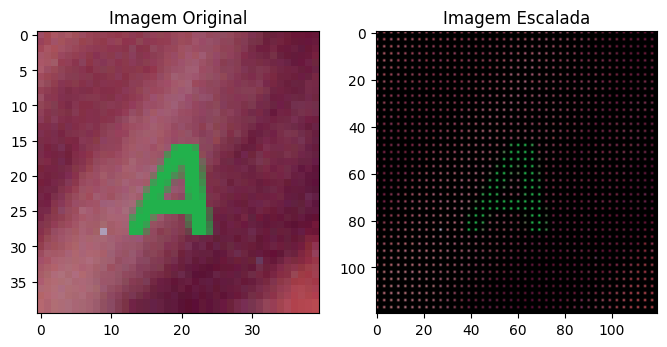

In [18]:
escala = 3

# Matriz 2 vezes maior:
matriz_ext = np.zeros((imagem.shape[1] * escala,
                    imagem.shape[0] * escala,3),dtype=np.uint8)

for i in range(imagem.shape[0]):
  for j in range(imagem.shape[1]):

      matriz_ext[i*escala,j*escala] = imagem[i,j]

plt.figure(figsize=(8,8))
# plt.subplot(linhas, colunas, posição)

plt.subplot(1,2,1)
plt.imshow(imagem)
plt.title("Imagem Original")

plt.subplot(1,2,2)
plt.imshow(matriz_ext)
plt.title("Imagem Escalada")

**Imagem escalada com Interpolação Nearest**

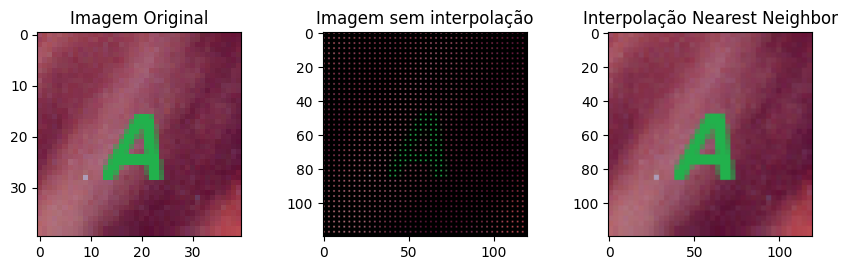

In [25]:
# Escala de aumento
escala = 3
# Nova matriz
matriz_n = np.zeros((imagem.shape[0] * escala,
                     imagem.shape[1] * escala, 3),dtype=np.uint8)

for i in range(imagem.shape[0]):
  for j in range(imagem.shape[1]):

    matriz_n[i*escala,j*escala] = imagem[i,j]

    # Range de 0,1,2,3...escala-1
    for i2 in range(escala):
      for j2 in range(escala):

            matriz_n[i*escala+i2,j*escala+j2] = imagem[i,j]

plt.figure(figsize=(10,10))
plt.subplots_adjust(wspace=0.4)

# plt.subplot(linhas, colunas, posição)
plt.subplot(1,3,1)
plt.imshow(imagem)
plt.title("Imagem Original")

plt.subplot(1,3,2)
plt.imshow(matriz_ext)
plt.title("Imagem sem interpolação")

plt.subplot(1,3,3)
plt.imshow(matriz_n)
plt.title("Interpolação Nearest Neighbor")

plt.show()

**Imagem escalada com Interpolação Bilinear e Bicúbica**

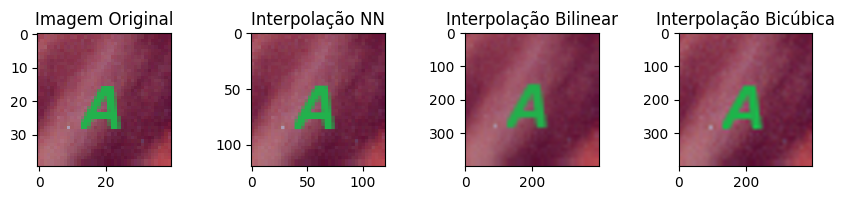

In [76]:
escala = 10
altura = imagem.shape[0]
largura = imagem.shape[1]

bilinear= np.zeros(
    (altura * escala, largura * escala, 3),dtype=np.uint8)

# Observação: O padrão do numpy é imagem[y, x] ()
for i in range(largura * escala):
    for j in range(altura * escala):

        # Coordenadas decimais, indicando a posição do novo píxel
        # considerando a imagem original
        x = i / escala
        y = j / escala

        # Coordenada correspondente na imagem original
        # Tipo inteiro extrai apenas a parte inteira, indicando o pixel
        x0 = int(x)
        y0 = int(y)

        # Coordenadas do próximo à direita e à baixo
        # Considera-se o menor valor para evitar de passar pela matriz
        x1 = min(x0 + 1, largura - 1)
        y1 = min(y0 + 1, altura - 1)

        # Distância para o pixel anterior
        dx = x - x0
        dy = y - y0

        # Quatro pixels vizinhos
        P1 = imagem[y0, x0]
        P2 = imagem[y0, x1]
        P3 = imagem[y1, x0]
        P4 = imagem[y1, x1]

        # Interpolação bilinear
        valor = ((1 - dx) * (1 - dy) * P1 +
                 dx * (1 - dy) * P2 +
                 (1 - dx) * dy * P3 +
                 dx *  dy * P4)

        bilinear[j, i] = valor

# Interpolação Bicubica para fins de comparação
# -----------------------------------------------------
bicubica = cv2.resize(imagem,None,fx=escala,fy=escala,
                      interpolation=cv2.INTER_CUBIC)
# -----------------------------------------------------

plt.figure(figsize=(10,10))
plt.subplots_adjust(wspace=0.6)

# plt.subplot(linhas, colunas, posição)
plt.subplot(1,4,1)
plt.imshow(imagem)
plt.title("Imagem Original")

plt.subplot(1,4,2)
plt.imshow(matriz_n)
plt.title("Interpolação NN")

plt.subplot(1,4,3)
plt.imshow(bilinear)
plt.title("Interpolação Bilinear")

plt.subplot(1,4,4)
plt.imshow(bicubica)
plt.title("Interpolação Bicúbica")

plt.show()

**Rotação com Nearest Neighbor**

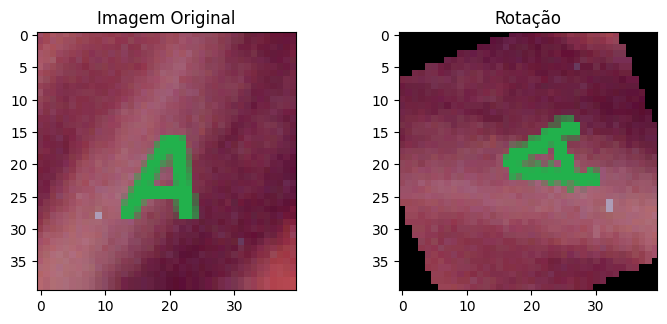

In [86]:
altura = imagem.shape[0]
largura = imagem.shape[1]

matriz_rot = np.zeros_like(imagem)
xcentro = largura / 2
ycentro = altura / 2

# As funções seno e cosseno utilizam radianos
angulo = math.radians(112)

for i in range(largura):
  for j in range(altura):

    x = i - xcentro
    y = j - ycentro

    xlinha = x * math.cos(angulo) - y * math.sin(angulo)
    ylinha = x * math.sin(angulo) + y * math.cos(angulo)

    xlinha = int(xlinha + xcentro)
    ylinha = int(ylinha + ycentro)

    if (0 <= xlinha < largura and 0 <= ylinha < altura):
            # Aqui já aplica o valor mais próximo, por transformar o valor
            # de referência para inteiro
            matriz_rot[j, i] = imagem[ylinha,xlinha]

plt.figure(figsize=(8,8))
plt.subplots_adjust(wspace=0.4)

# plt.subplot(linhas, colunas, posição)
plt.subplot(1,2,1)
plt.imshow(imagem)
plt.title("Imagem Original")

plt.subplot(1,2,2)
plt.imshow(matriz_rot)
plt.title("Rotação")

plt.show()

**Rotação com interpolação bilinear**

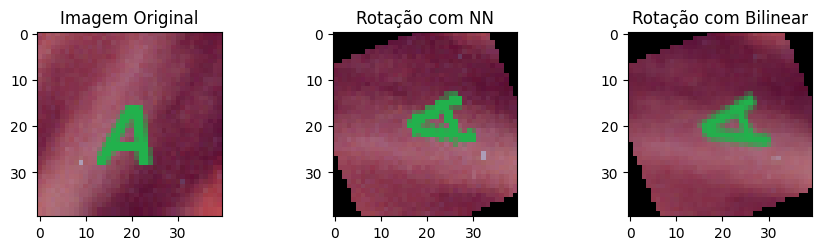

In [87]:
altura = imagem.shape[0]
largura = imagem.shape[1]

matriz_rot_bilinear = np.zeros_like(imagem)
xcentro = largura / 2
ycentro = altura / 2

# As funções seno e cosseno utilizam radianos
angulo = math.radians(112)

for i in range(largura):
  for j in range(altura):

    x = i - xcentro
    y = j - ycentro

    xlinha = x * math.cos(angulo) - y * math.sin(angulo)
    ylinha = x * math.sin(angulo) + y * math.cos(angulo)

    xlinha = xlinha + xcentro
    ylinha = ylinha + ycentro

    if (0 <= xlinha < largura and 0 <= ylinha < altura):

            # Processo de Interpolação (Bilinear)
            # ------------------------------------------------
            x0 = int(xlinha)
            y0 = int(ylinha)

            x1 = min(x0 + 1, largura - 1)
            y1 = min(y0 + 1, altura - 1)

            dx = xlinha - x0
            dy = ylinha - y0

            P1 = imagem[y0, x0]
            P2 = imagem[y0, x1]
            P3 = imagem[y1, x0]
            P4 = imagem[y1, x1]

            valor = (
                (1 - dx) * (1 - dy) * P1 +
                dx * (1 - dy) * P2 +
                (1 - dx) * dy * P3 +
                dx * dy * P4
            )

            matriz_rot_bilinear[j, i] = np.uint8(np.clip(valor, 0, 255))

plt.figure(figsize=(10,10))
plt.subplots_adjust(wspace=0.6)

# plt.subplot(linhas, colunas, posição)
plt.subplot(1,3,1)
plt.imshow(imagem)
plt.title("Imagem Original")

plt.subplot(1,3,2)
plt.imshow(matriz_rot)
plt.title("Rotação com NN")

plt.subplot(1,3,3)
plt.imshow(matriz_rot_bilinear)
plt.title("Rotação com Bilinear")

plt.show()

**Operações ponto-a-ponto: Brilho**

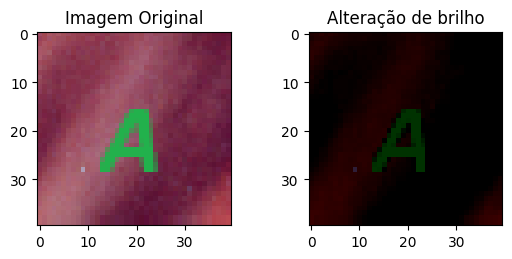

In [140]:
img_operada = np.zeros_like(imagem)
largura = img_operada.shape[1]
altura = img_operada.shape[0]

# Brilho:
brilho = -127

for i in range(largura):
  for j in range(altura):

    # Aplica um limite dos valores
    # Mudamos para np.int16 para evitar erros de overflow
    img_operada[j,i] = np.clip(imagem[j,i].astype(np.int16) +
                               brilho, 0, 255)

plt.figure(figsize=(6,6))
plt.subplots_adjust(wspace=0.4)

plt.subplot(1,2,1)
plt.imshow(imagem)
plt.title("Imagem Original")

plt.subplot(1,2,2)
plt.imshow(img_operada)
plt.title("Alteração de brilho")

plt.show()

**Operações ponto-a-ponto: Contraste**

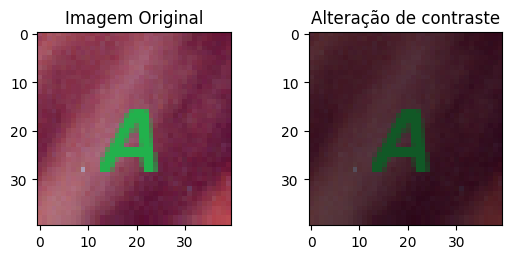

In [139]:
img_operada = np.zeros_like(imagem)
largura = img_operada.shape[1]
altura = img_operada.shape[0]

# contraste:
contraste = 0.5

for i in range(largura):
  for j in range(altura):

    # Aplica um limite dos valores
    # Mudamos para np.int16 para evitar erros de overflow
    img_operada[j,i] = np.clip(imagem[j,i].astype(np.int16) *
                               contraste, 0, 255)

plt.figure(figsize=(6,6))
plt.subplots_adjust(wspace=0.4)

plt.subplot(1,2,1)
plt.imshow(imagem)
plt.title("Imagem Original")

plt.subplot(1,2,2)
plt.imshow(img_operada)
plt.title("Alteração de contraste")

plt.show()

**Operações ponto-a-ponto: Negativo**

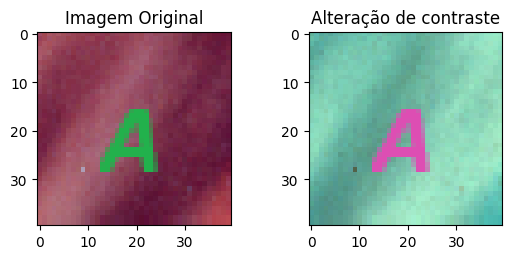

In [150]:
img_operada = np.zeros_like(imagem)
largura = img_operada.shape[1]
altura = img_operada.shape[0]

for i in range(largura):
  for j in range(altura):

    img_operada[j,i] = np.clip(255 - imagem[j,i], 0, 255)

plt.figure(figsize=(6,6))
plt.subplots_adjust(wspace=0.4)

plt.subplot(1,2,1)
plt.imshow(imagem)
plt.title("Imagem Original")

plt.subplot(1,2,2)
plt.imshow(img_operada)
plt.title("Alteração de contraste")

plt.show()

**Operações ponto-a-ponto: Limiarização**

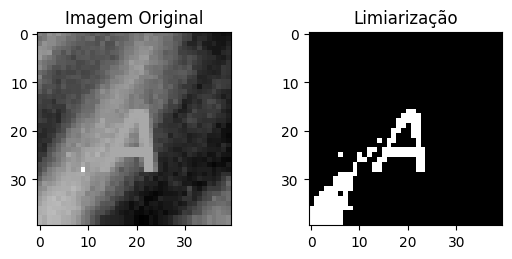

In [184]:
# Para a limiarização, a imagem é convertida para preto e branco
img_gray = cv2.cvtColor(imagem, cv2.COLOR_RGB2GRAY)
img_operada = np.zeros_like(img_gray)

largura = img_operada.shape[1]
altura = img_operada.shape[0]

limite = 122

for i in range(largura):
  for j in range(altura):

    if img_gray[j,i] < limite:
      img_operada[j,i] = 0
    else:
      img_operada[j,i] = 255


plt.figure(figsize=(6,6))
plt.subplots_adjust(wspace=0.4)

plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Imagem Original")

plt.subplot(1,2,2)
plt.imshow(img_operada, cmap='gray')
plt.title("Limiarização")

plt.show()